# CelebA Dataset Exploration
Visualize images, check attribute distributions, verify data pipeline.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from pet_gen.data.celeba_dataset import CelebADataset
from pet_gen.data.transforms import get_train_transform, get_eval_transform

In [2]:
CELEBA_ROOT = '../data/celeba'
SELECTED_ATTRS = [
    'Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Gray_Hair',
    'Straight_Hair', 'Wavy_Hair',
    'Arched_Eyebrows', 'Bushy_Eyebrows',
    'Narrow_Eyes', 'Big_Nose', 'Pointy_Nose',
    'High_Cheekbones', 'Oval_Face', 'Pale_Skin', 'Chubby',
]

## 1. Load Dataset

In [3]:
train_ds = CelebADataset(CELEBA_ROOT, split='train', selected_attributes=SELECTED_ATTRS)
val_ds = CelebADataset(CELEBA_ROOT, split='val', selected_attributes=SELECTED_ATTRS)
test_ds = CelebADataset(CELEBA_ROOT, split='test', selected_attributes=SELECTED_ATTRS)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 162770 | Val: 19867 | Test: 19962


## 2. Attribute Distribution

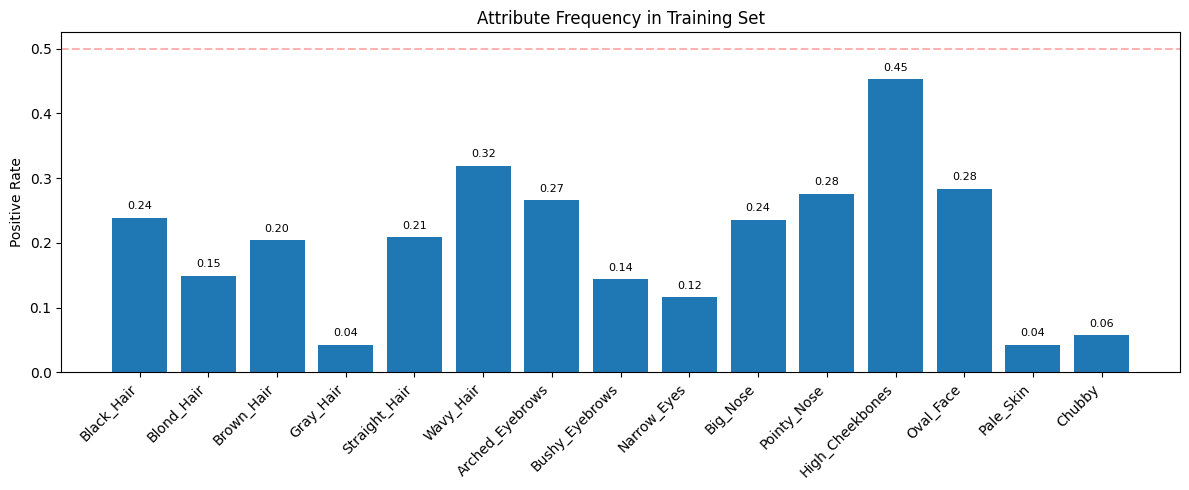

In [4]:
pos_rates = train_ds.labels.mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(SELECTED_ATTRS)), pos_rates)
ax.set_xticks(range(len(SELECTED_ATTRS)))
ax.set_xticklabels(SELECTED_ATTRS, rotation=45, ha='right')
ax.set_ylabel('Positive Rate')
ax.set_title('Attribute Frequency in Training Set')
ax.axhline(y=0.5, color='r', linestyle='--', alpha=0.3)

for bar, rate in zip(bars, pos_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{rate:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Sample Images

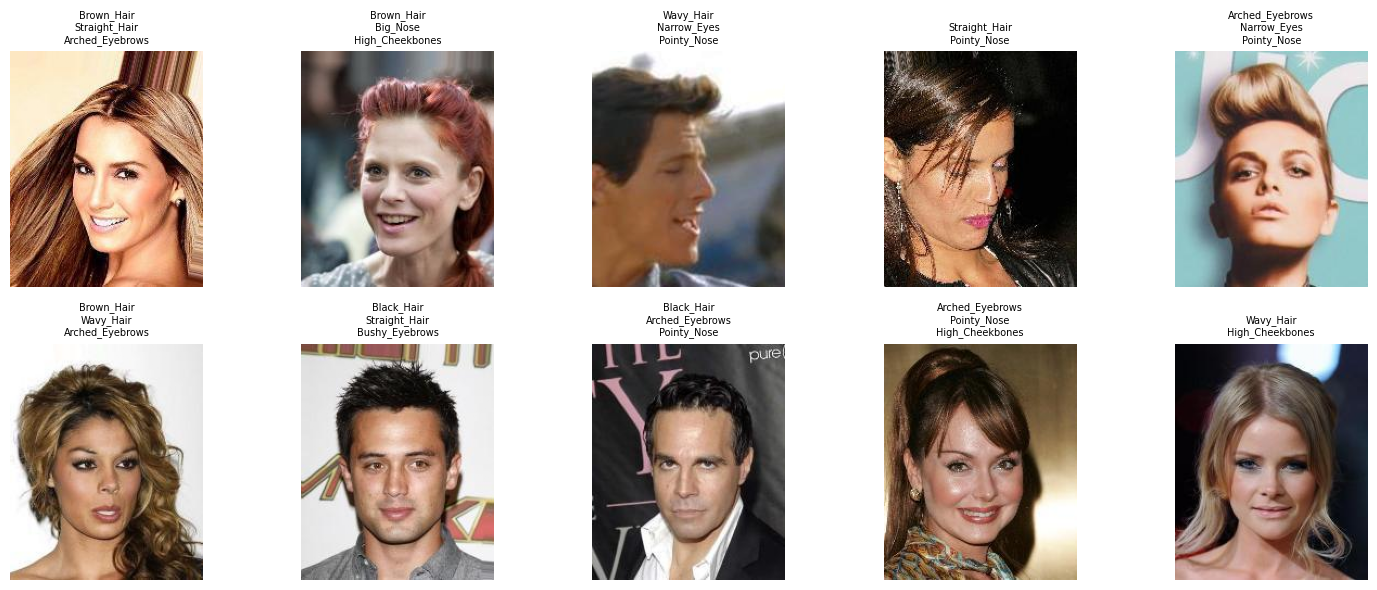

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img, label = train_ds[i]
    if img.shape[0] == 3:
        img = img.permute(1, 2, 0)
    img = img.numpy()
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    active = [SELECTED_ATTRS[j] for j in range(len(SELECTED_ATTRS)) if label[j] > 0.5]
    ax.set_title('\n'.join(active[:3]), fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Pos Weight for Loss

In [6]:
pw = train_ds.compute_pos_weight()
for name, w in zip(SELECTED_ATTRS, pw):
    print(f'{name:20s} pos_weight={w:.2f}')

Black_Hair           pos_weight=3.18
Blond_Hair           pos_weight=5.71
Brown_Hair           pos_weight=3.90
Gray_Hair            pos_weight=22.60
Straight_Hair        pos_weight=3.79
Wavy_Hair            pos_weight=2.13
Arched_Eyebrows      pos_weight=2.76
Bushy_Eyebrows       pos_weight=5.96
Narrow_Eyes          pos_weight=7.63
Big_Nose             pos_weight=3.25
Pointy_Nose          pos_weight=2.63
High_Cheekbones      pos_weight=1.21
Oval_Face            pos_weight=2.53
Pale_Skin            pos_weight=22.24
Chubby               pos_weight=16.34


## 5. Verify Transforms

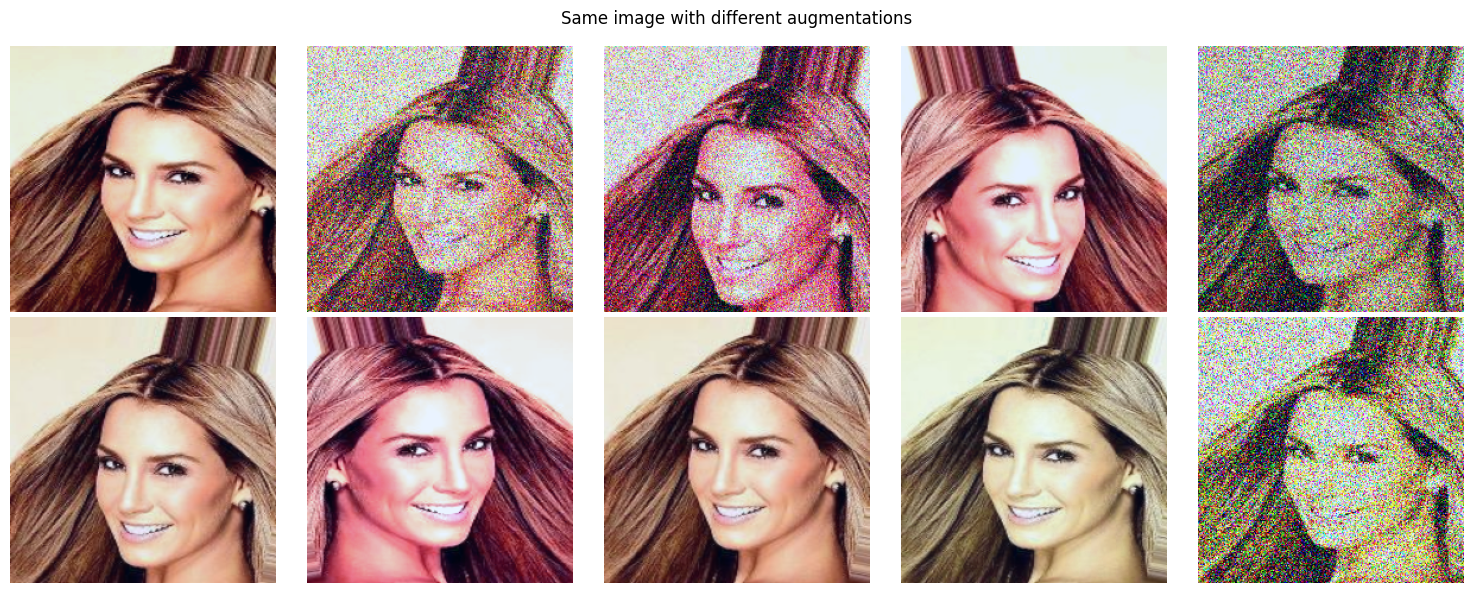

In [7]:
train_t = get_train_transform(224)
train_ds_aug = CelebADataset(CELEBA_ROOT, split='train',
                              selected_attributes=SELECTED_ATTRS,
                              transform=train_t)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img, _ = train_ds_aug[0]  # same image, different augmentations
    img = img.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.axis('off')
fig.suptitle('Same image with different augmentations')
plt.tight_layout()
plt.show()